# Visualización y Suavizado de Series de Tiempo (Media Móvil)

**Finalidad del Notebook:**  
El propósito de este documento es avanzar en el procesamiento de la señal musical aplicando técnicas de **suavizado de datos**. Dado que las notas MIDI pueden presentar alta varianza (saltos abruptos de *pitch*), implementaremos una **Media Móvil (*Rolling Window*)** utilizando la librería Pandas. Esto nos permitirá filtrar el ruido de la serie de tiempo original, revelando la tendencia melódica subyacente y la estructura general de la canción a través de un gráfico comparativo (Datos originales vs. Tendencia suavizada).

### 1. Importación de Librerías Base
* `os`, `glob`, `random`: Para la manipulación de rutas y selección de archivos en nuestro directorio.
* `mido`: Herramienta especializada para la lectura y extracción de eventos temporales de archivos `.midi`.
* `pandas`: Esencial en este notebook, ya que utilizaremos su estructura `Series` y el método `.rolling()` para calcular la media móvil.
* `numpy`: Soporte de operaciones algebraicas y numéricas.
* `matplotlib.pyplot` y `seaborn`: Encargados del motor de renderizado gráfico de alta calidad.


In [1]:
import os
from glob import glob
import random
import mido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Recolección del Dataset
Definimos la constante `ruta_base` que apunta al directorio raíz de nuestro corpus musical (`maestro-v3.0.0`). Posteriormente, a través del módulo `glob` y el flag `recursive=True`, indexamos todos los archivos `.midi` disponibles, creando una lista consolidada (`archivos`) lista para ser iterada.


In [2]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

### 3. Función de Extracción y Suavizado Estadístico
Se declara la función central `visualizar_suavizado`, la cual introduce parámetros de control como el tamaño de la `ventana` (por defecto 15 eventos) y el `limite` de archivos a procesar. La lógica sigue este flujo:

1. **Parseo y Extracción:** Se recorre cada archivo iterando a través de sus mensajes `note_on`, acumulando el tiempo real y almacenando los valores de *pitch* (altura de la nota).
2. **Transformación Matemática (Suavizado):** Se convierte el vector de notas en un objeto `pd.Series(notas)`. A este objeto se le aplica el método `.rolling(window=ventana, center=True).mean()`, lo que calcula el promedio aritmético de las notas dentro de la ventana móvil, creando una curva suavizada (`media_movil`).
3. **Renderizado de Capas Gráficas:** Se despliega un lienzo de 15x5 pulgadas. Se dibuja una primera capa como un diagrama de dispersión (*scatter*) azul semitransparente que representa la matriz original. Sobre ella, se inyecta la curva roja resultante de la media móvil, contrastando visualmente la composición cruda contra la tendencia centralizada.


In [ ]:
def visualizar_suavizado(lista_archivos, ventana=15, limite=3):
    for i, ruta in enumerate(lista_archivos[:limite]):
        mid = mido.MidiFile(ruta)
        tiempos = []
        notas = []
        tiempo_actual = 0
        
        for msg in mid:
            tiempo_actual += msg.time
            if msg.type == 'note_on' and msg.velocity > 0:
                tiempos.append(tiempo_actual)
                notas.append(msg.note)
        
        if not notas:
            continue

        serie_notas = pd.Series(notas)
        media_movil = serie_notas.rolling(window=ventana, center=True).mean()
        
        plt.figure(figsize=(15, 5))
        
        plt.scatter(tiempos, notas, s=3, color='tab:blue', alpha=0.5, label='Notas Originales')
        
        plt.plot(tiempos, media_movil, color='red', linewidth=1.5, label=f'Media Móvil (n={ventana})')
        
        plt.title(f"Suavizado de Serie: {os.path.basename(ruta)}")
        plt.xlabel("Tiempo")
        plt.ylabel("Pitch (Nota)")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

### 4. Ejecución del Proceso de Suavizado
Mandamos a llamar a nuestro algoritmo pasándole el conjunto de archivos en formato de lista. El algoritmo iterará sobre el límite predefinido, extraerá las melodías, calculará la transformación estadística de media móvil y renderizará los gráficos individuales demostrando el filtrado de ruido.


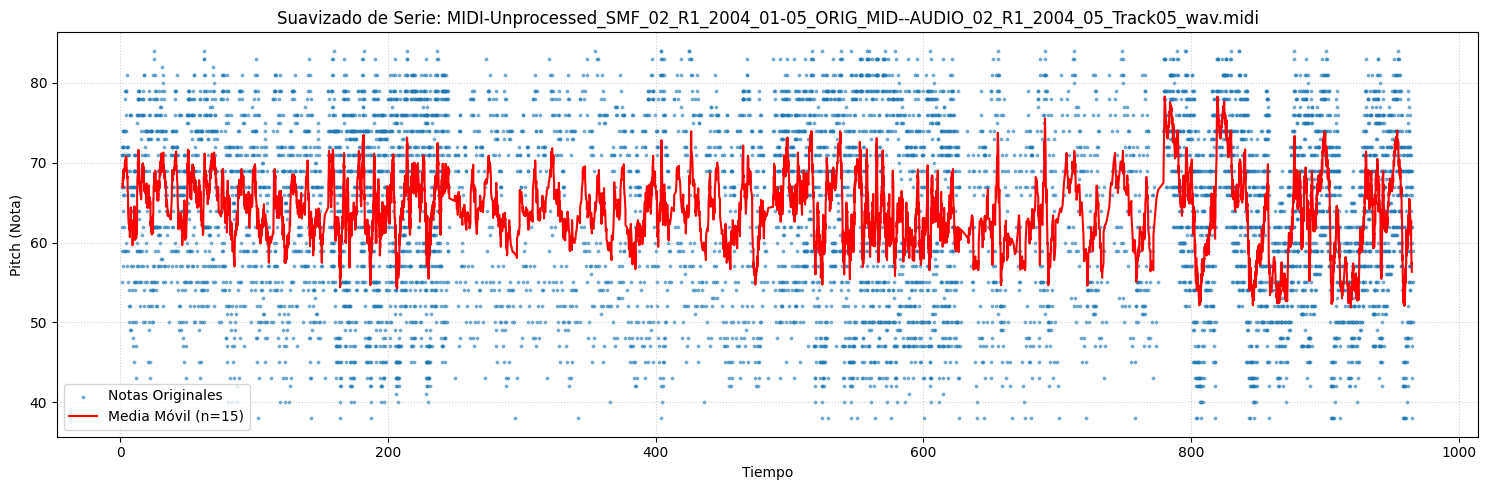

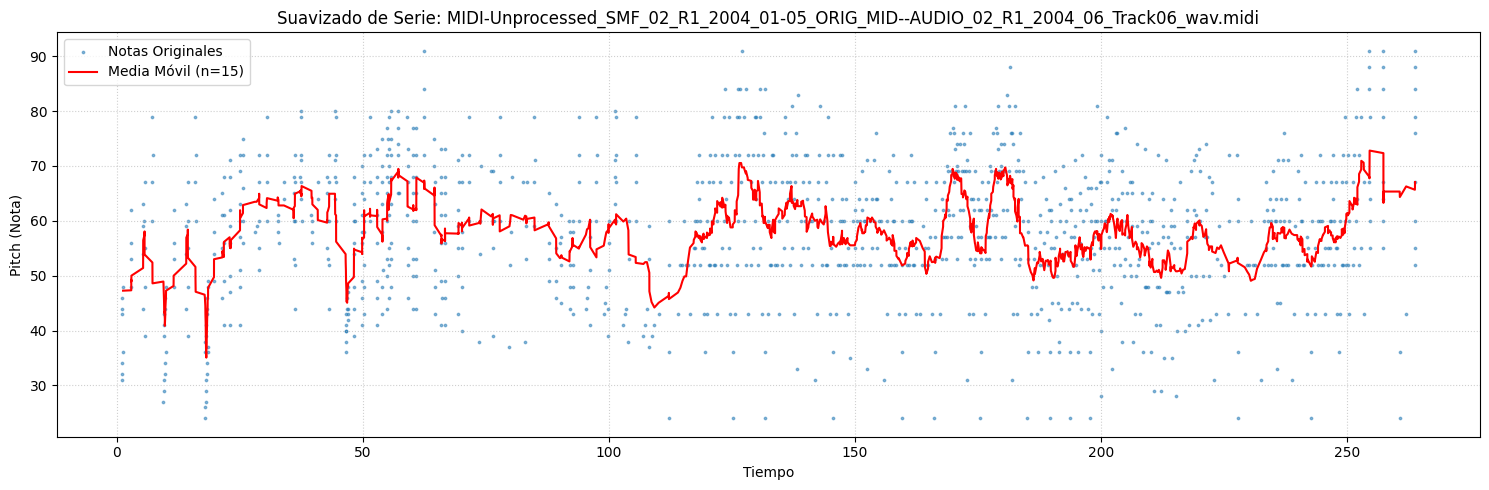

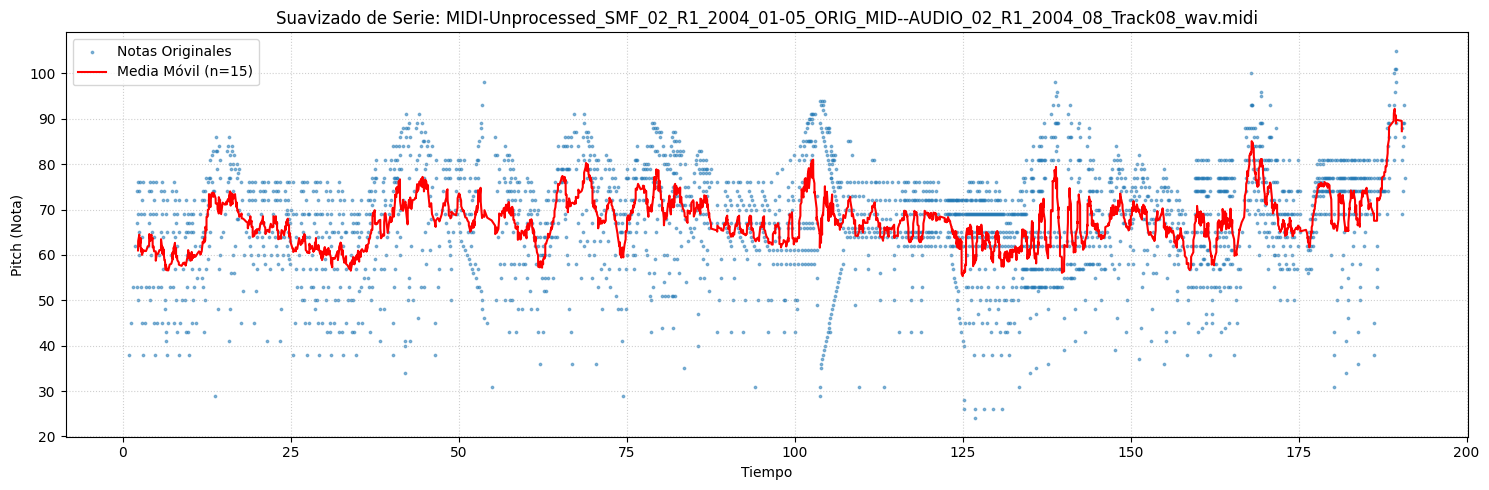

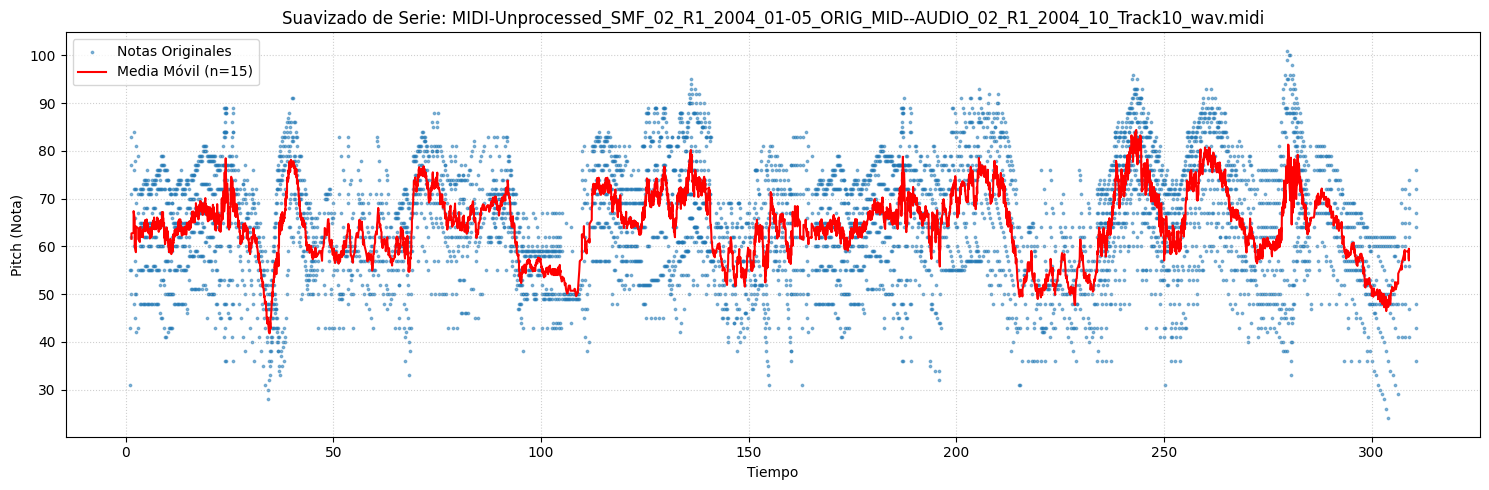

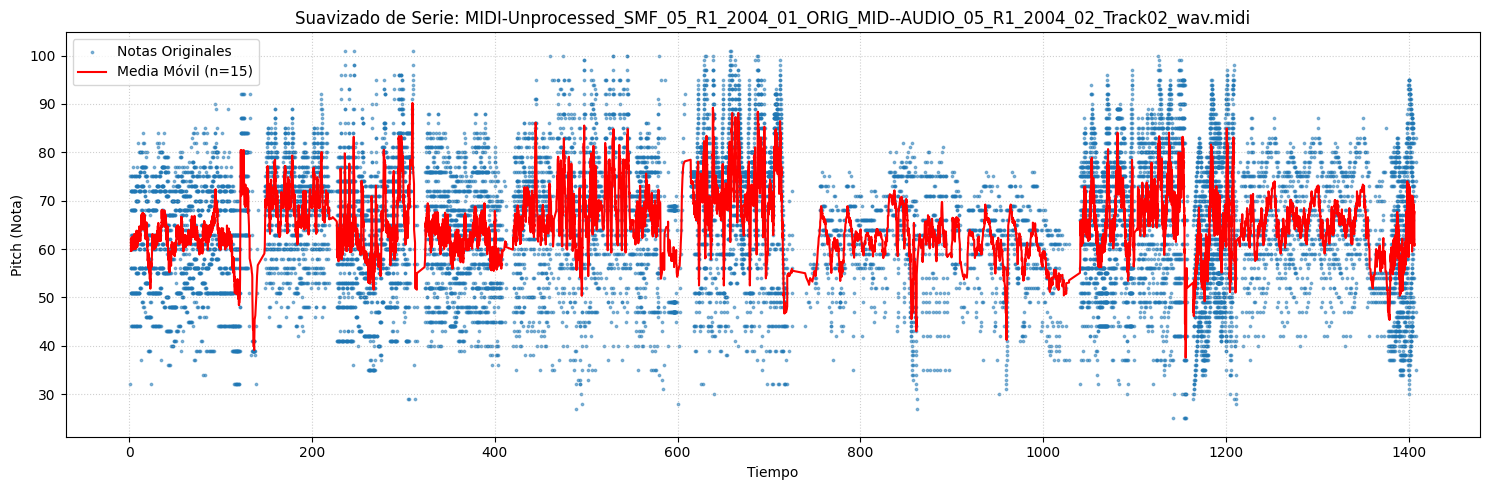

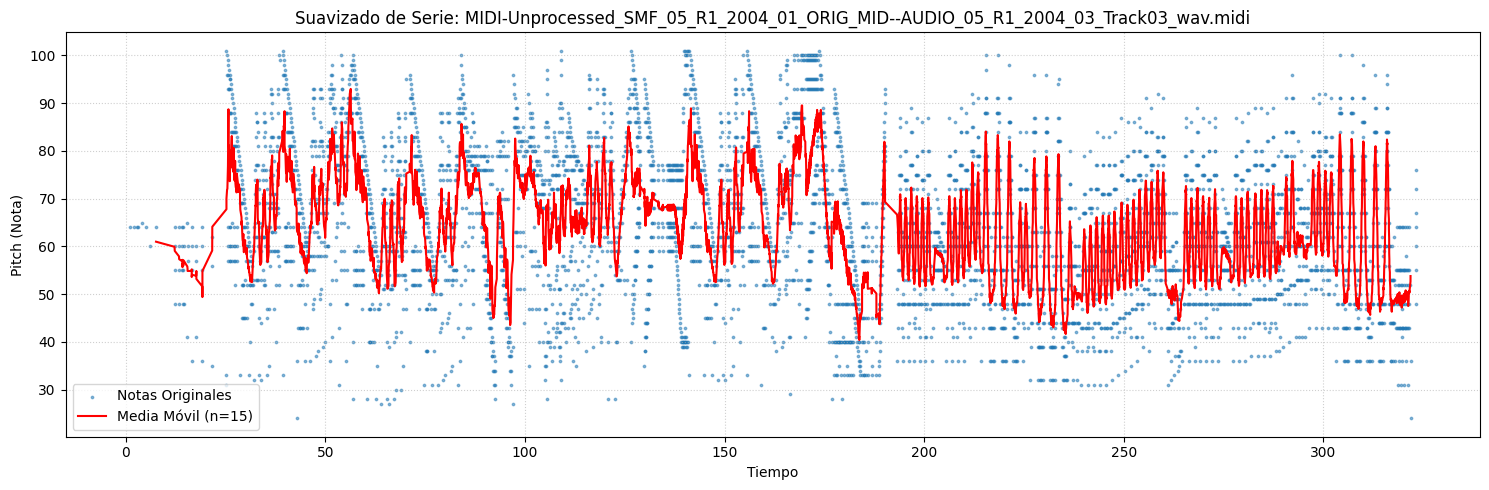

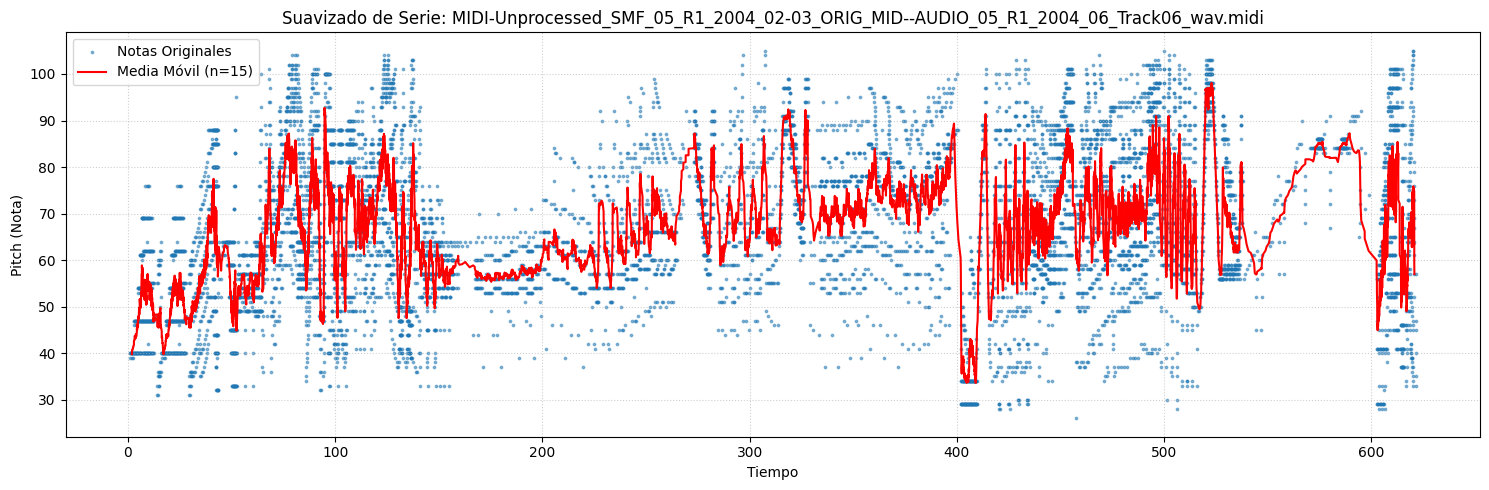

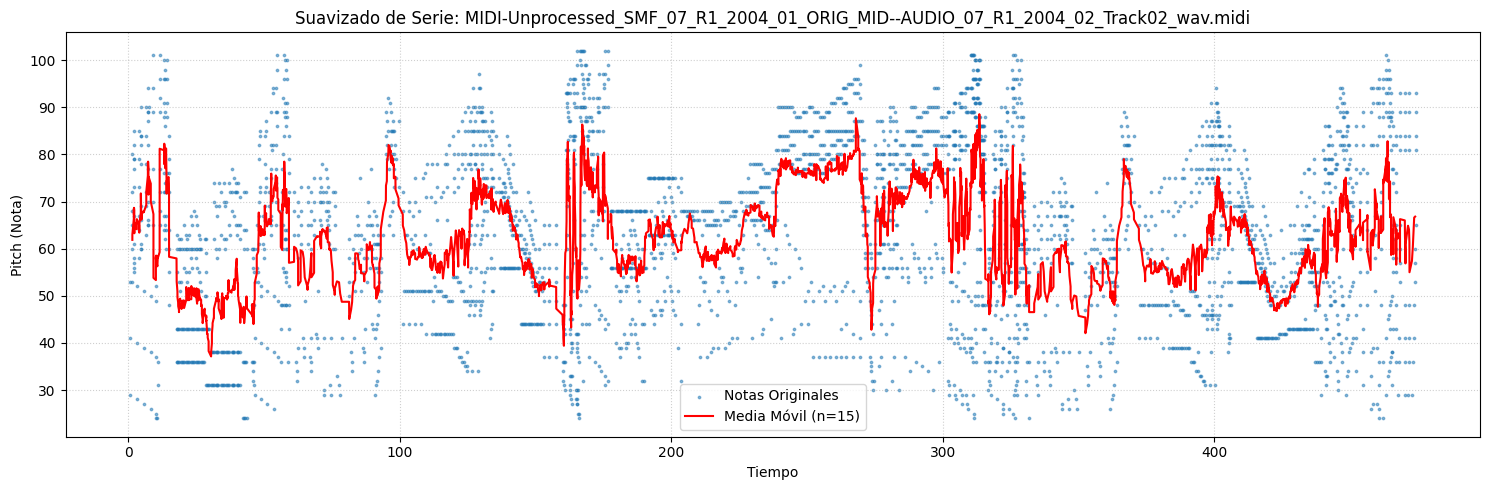

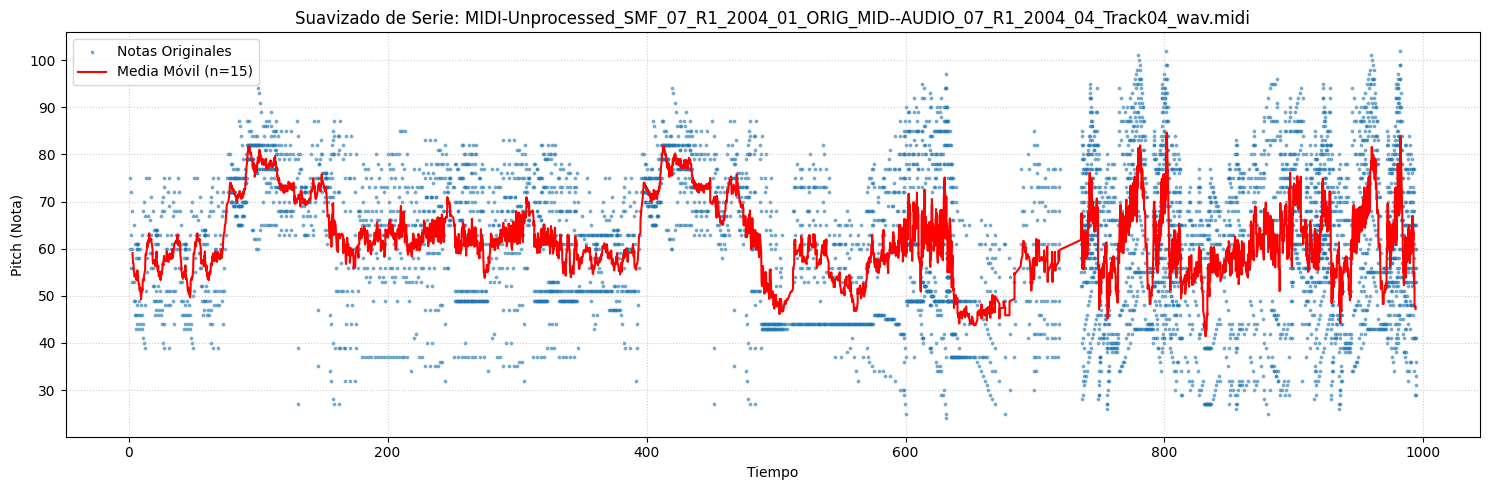

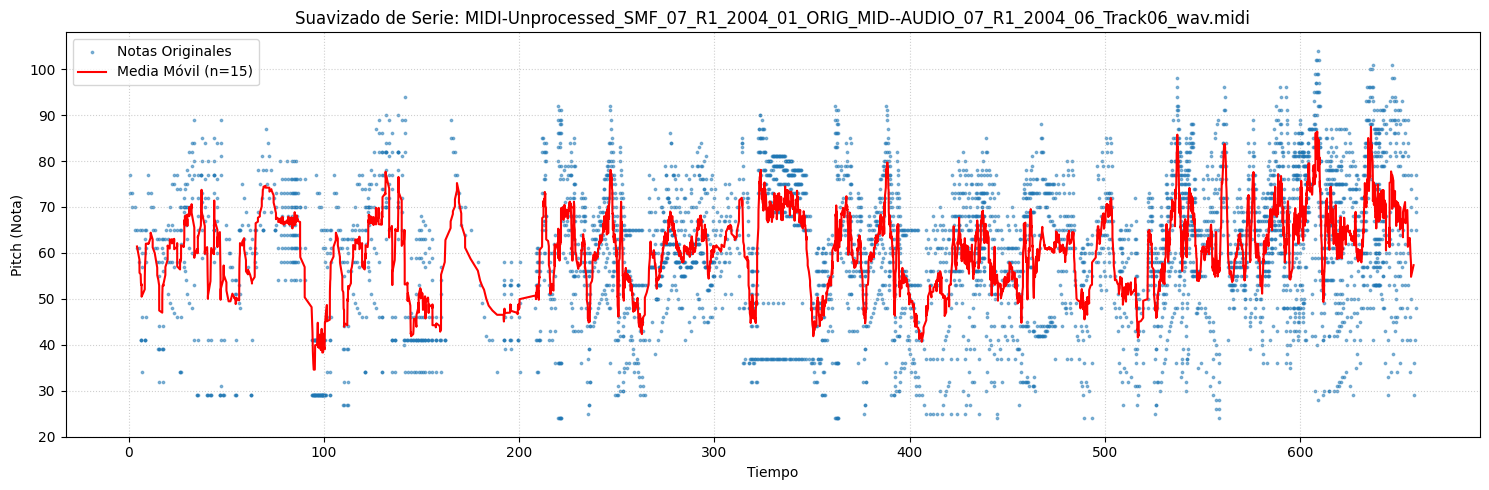

In [4]:
visualizar_suavizado(archivos, ventana=15, limite=10)